In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import warnings
import pandas as pd
from sklearn.model_selection import train_test_split
import mlflow
from mlflow.models import infer_signature
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, 
                 activation='relu', dropout=0.0, batch_norm=False):
        super(FlexibleMLP, self).__init__()
        
        # Activation function mapping
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU(0.1),
            'elu': nn.ELU()
        }
        
        layers = []
        prev_size = input_size
        
        for i, hidden_size in enumerate(hidden_sizes):
            # Linear layer
            layers.append(nn.Linear(prev_size, hidden_size))
            
            # Batch normalization (optional)
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            # Activation
            layers.append(activations[activation])
            
            # Dropout (optional)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size
        
        # Output layer (no activation - use with CrossEntropyLoss)
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# Convert boolean columns to int (0/1) in the DataFrames
def convert_bool_to_int(df):
    """Convert boolean columns to int type"""
    df_converted = df.copy()
    for col in df_converted.select_dtypes(include=['bool']).columns:
        df_converted[col] = df_converted[col].astype(int)
    return df_converted

In [2]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

RANDOM_SEED = 19
scaler = StandardScaler()

df = pd.read_csv("../data/interim/telco_customer_churn_preprocessed.csv")

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

X_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X_train[['tenure', 'MonthlyCharges', 'TotalCharges']])
X_test[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(X_test[['tenure', 'MonthlyCharges', 'TotalCharges']])

# Apply conversion to train and test sets
X_train = convert_bool_to_int(X_train)
X_test = convert_bool_to_int(X_test)


# Create evaluation dataset
eval_data = X_test.copy()
eval_data["Churn"] = y_test
# dataset to log
df_train = pd.concat([X_train, y_train], axis=1)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader for more efficient batching
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
# Training with DataLoader
model = FlexibleMLP(
    input_size=X_train.shape[1],
    hidden_sizes=[256, 128, 64],  # More capacity
    output_size=2,
    activation='relu',
    dropout=0.3,
    batch_norm=True
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Evaluation
    if (epoch + 1) % 5 == 0:
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X)
                _, predicted = torch.max(outputs, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
        
        accuracy = 100 * correct / total
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, Test Accuracy: {accuracy:.2f}%')

Epoch [5/50], Loss: 0.4242, Test Accuracy: 80.48%
Epoch [10/50], Loss: 0.4187, Test Accuracy: 81.26%
Epoch [15/50], Loss: 0.4123, Test Accuracy: 81.12%
Epoch [20/50], Loss: 0.4046, Test Accuracy: 81.69%
Epoch [25/50], Loss: 0.4129, Test Accuracy: 81.26%
Epoch [30/50], Loss: 0.4029, Test Accuracy: 81.05%
Epoch [35/50], Loss: 0.3931, Test Accuracy: 81.19%
Epoch [40/50], Loss: 0.3861, Test Accuracy: 79.84%
Epoch [45/50], Loss: 0.3793, Test Accuracy: 79.77%
Epoch [50/50], Loss: 0.3980, Test Accuracy: 80.41%


In [ ]:
import mlflow
import mlflow.pytorch
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report)


def train_with_mlflow(model, train_loader, test_loader, X_test_tensor, y_test_tensor, run_name,
                      criterion, optimizer, epochs, experiment_name="churn_prediction"):
    """
    Train PyTorch model with MLflow tracking
    """
    
    # Set experiment
    mlflow.set_experiment(experiment_name)
    
    # Start MLflow run
    with mlflow.start_run(run_name=run_name) as run:
        
        # Log model parameters
        mlflow.log_params({
            "model_type": "FlexibleMLP",
            "input_size": model.network[0].in_features,
            "hidden_layers": str([layer.out_features for layer in model.network if isinstance(layer, nn.Linear) and layer != model.network[-1]]),
            "output_size": model.network[-1].out_features,
            "activation": str(type(model.network[2]).__name__) if len(model.network) > 2 else "ReLU",
            "dropout": next((layer.p for layer in model.network if isinstance(layer, nn.Dropout)), 0.0),
            "batch_norm": any(isinstance(layer, nn.BatchNorm1d) for layer in model.network),
            "optimizer": type(optimizer).__name__,
            "learning_rate": optimizer.param_groups[0]['lr'],
            "criterion": type(criterion).__name__,
            "epochs": epochs,
            "batch_size": train_loader.batch_size if train_loader else 32
        })
        
        # Training loop with metrics tracking
        train_losses = []
        test_losses = []
        train_accuracies = []
        test_accuracies = []
        
        for epoch in range(epochs):
            # Training phase
            model.train()
            epoch_train_loss = 0
            correct_train = 0
            total_train = 0
            
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                epoch_train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_train += batch_y.size(0)
                correct_train += (predicted == batch_y).sum().item()
            
            avg_train_loss = epoch_train_loss / len(train_loader)
            train_accuracy = 100 * correct_train / total_train
            train_losses.append(avg_train_loss)
            train_accuracies.append(train_accuracy)
            
            # Evaluation phase
            model.eval()
            epoch_test_loss = 0
            correct_test = 0
            total_test = 0
            all_preds = []
            all_labels = []
            all_probs = []
            
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    epoch_test_loss += loss.item()
                    
                    probs = torch.softmax(outputs, dim=1)
                    _, predicted = torch.max(outputs, 1)
                    
                    total_test += batch_y.size(0)
                    correct_test += (predicted == batch_y).sum().item()
                    
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(batch_y.cpu().numpy())
                    all_probs.extend(probs[:, 1].cpu().numpy())
            
            avg_test_loss = epoch_test_loss / len(test_loader)
            test_accuracy = 100 * correct_test / total_test
            test_losses.append(avg_test_loss)
            test_accuracies.append(test_accuracy)
            
            # Log metrics every epoch
            mlflow.log_metrics({
                "train_loss": avg_train_loss,
                "train_accuracy": train_accuracy,
                "test_loss": avg_test_loss,
                "test_accuracy": test_accuracy
            }, step=epoch)
            
            # Print progress
            if (epoch + 1) % 5 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], '
                      f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, '
                      f'Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')
        
        # Calculate final metrics
        final_metrics = {
            "final_train_loss": train_losses[-1],
            "final_train_accuracy": train_accuracies[-1],
            "final_test_loss": test_losses[-1],
            "final_test_accuracy": test_accuracies[-1],
            "accuracy": accuracy_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds, average='binary'),
            "recall": recall_score(all_labels, all_preds, average='binary'),
            "f1_score": f1_score(all_labels, all_preds, average='binary'),
            "roc_auc": roc_auc_score(all_labels, all_probs)
        }
        
        # Log final metrics
        mlflow.log_metrics(final_metrics)
        
        # Log the model
        signature = infer_signature(X_test_tensor.numpy(), 
                                    torch.tensor(all_preds).numpy().reshape(-1, 1))
        
        mlflow.pytorch.log_model(
            model,
            "model",
            signature=signature,
            registered_model_name=f"{experiment_name}_model"
        )
        
        
        print("\n" + "="*50)
        print("MLflow Run Completed!")
        print(f"Run ID: {run.info.run_id}")
        print(f"Experiment ID: {run.info.experiment_id}")
        print(f"Artifact URI: {run.info.artifact_uri}")
        print("="*50)
        
        # Print final metrics
        print("\n📊 Final Model Metrics:")
        for metric, value in final_metrics.items():
            print(f"  {metric}: {value:.4f}")
        
        return model, run.info.run_id

In [4]:
# Training with DataLoader
model = FlexibleMLP(
    input_size=X_train.shape[1],
    hidden_sizes=[256, 128, 64],  # More capacity
    output_size=2,
    activation='relu',
    dropout=0.3,
    batch_norm=True
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train with MLflow tracking
trained_model, run_id = train_with_mlflow(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    run_name="mlp vanilla",
    criterion=criterion,
    optimizer=optimizer,
    epochs=50,
    experiment_name="telco_churn_classification"
)

Epoch [5/50], Train Loss: 0.4252, Train Acc: 79.80%, Test Loss: 0.4032, Test Acc: 80.84%
Epoch [10/50], Train Loss: 0.4209, Train Acc: 79.39%, Test Loss: 0.4093, Test Acc: 80.41%
Epoch [15/50], Train Loss: 0.4118, Train Acc: 80.58%, Test Loss: 0.4054, Test Acc: 81.83%
Epoch [20/50], Train Loss: 0.4180, Train Acc: 80.67%, Test Loss: 0.4066, Test Acc: 80.70%
Epoch [25/50], Train Loss: 0.4025, Train Acc: 80.19%, Test Loss: 0.4061, Test Acc: 81.62%
Epoch [30/50], Train Loss: 0.4084, Train Acc: 80.81%, Test Loss: 0.4115, Test Acc: 81.12%
Epoch [35/50], Train Loss: 0.3930, Train Acc: 81.27%, Test Loss: 0.4206, Test Acc: 80.98%
Epoch [40/50], Train Loss: 0.3931, Train Acc: 81.51%, Test Loss: 0.4324, Test Acc: 80.55%
Epoch [45/50], Train Loss: 0.4031, Train Acc: 81.26%, Test Loss: 0.4217, Test Acc: 80.98%


2026/04/05 01:23:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 01:23:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch [50/50], Train Loss: 0.3759, Train Acc: 81.75%, Test Loss: 0.4274, Test Acc: 80.41%


2026/04/05 01:23:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



MLflow Run Completed!
Run ID: a00574f9394b4b87b14a7369a346436d
Experiment ID: 1
Artifact URI: /workspaces/fiap-tech-challenge-fase-1/notebooks/../artifacts/a00574f9394b4b87b14a7369a346436d/artifacts

📊 Final Model Metrics:
  final_train_loss: 0.3759
  final_train_accuracy: 81.7536
  final_test_loss: 0.4274
  final_test_accuracy: 80.4116
  accuracy: 0.8041
  precision: 0.6441
  recall: 0.5856
  f1_score: 0.6134
  roc_auc: 0.8401


Successfully registered model 'telco_churn_classification_model'.
Created version '1' of model 'telco_churn_classification_model'.


Threshold: 0.10 | Recall: 0.9225 | Precision: 0.4172 | F1: 0.5745
Threshold: 0.15 | Recall: 0.8663 | Precision: 0.4451 | F1: 0.5880
Threshold: 0.20 | Recall: 0.8503 | Precision: 0.4732 | F1: 0.6080
Threshold: 0.25 | Recall: 0.8155 | Precision: 0.4951 | F1: 0.6162
Threshold: 0.30 | Recall: 0.7647 | Precision: 0.5135 | F1: 0.6144
Threshold: 0.35 | Recall: 0.7326 | Precision: 0.5524 | F1: 0.6299
Threshold: 0.40 | Recall: 0.7059 | Precision: 0.5828 | F1: 0.6385
Threshold: 0.45 | Recall: 0.6524 | Precision: 0.6193 | F1: 0.6354
Threshold: 0.50 | Recall: 0.5856 | Precision: 0.6441 | F1: 0.6134
Threshold: 0.55 | Recall: 0.5053 | Precision: 0.6726 | F1: 0.5771
Threshold: 0.60 | Recall: 0.4251 | Precision: 0.6974 | F1: 0.5282
Threshold: 0.65 | Recall: 0.3449 | Precision: 0.7167 | F1: 0.4657
Threshold: 0.70 | Recall: 0.2219 | Precision: 0.7281 | F1: 0.3402
Threshold: 0.75 | Recall: 0.1497 | Precision: 0.7778 | F1: 0.2511
Threshold: 0.80 | Recall: 0.0802 | Precision: 0.8333 | F1: 0.1463
Threshold:

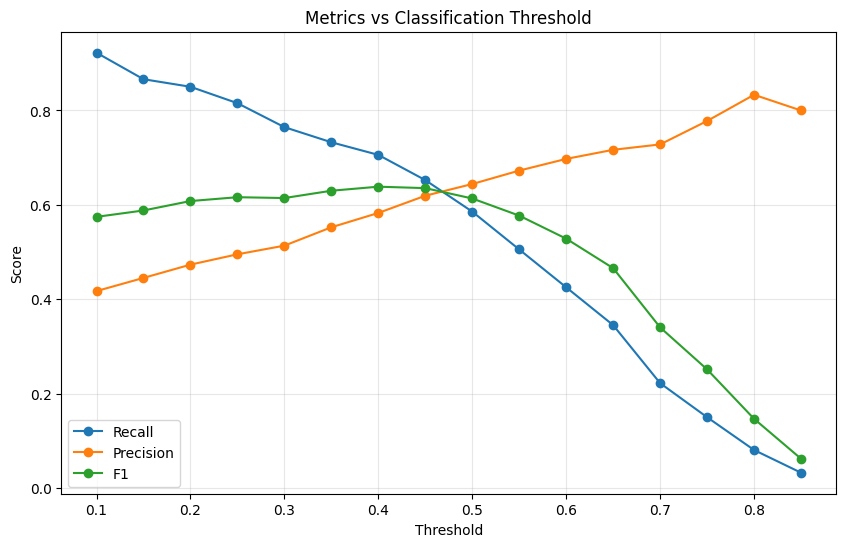


New recall with threshold 0.3: 0.7647


In [5]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

def find_best_threshold(model, test_loader, X_test_tensor, y_test_tensor):
    """Find optimal threshold to balance recall and precision"""
    
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        y_true = y_test_tensor.cpu().numpy()
    
    # Try different thresholds
    thresholds = np.arange(0.1, 0.9, 0.05)
    results = []
    
    for threshold in thresholds:
        y_pred = (probs >= threshold).astype(int)
        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        results.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1': f1
        })
        
        print(f"Threshold: {threshold:.2f} | Recall: {recall:.4f} | Precision: {precision:.4f} | F1: {f1:.4f}")
    
    # Find threshold that gives best recall while maintaining reasonable precision
    best_f1 = max(results, key=lambda x: x['f1'])
    best_recall = max(results, key=lambda x: x['recall'])
    
    print(f"\nBest F1 threshold: {best_f1['threshold']:.2f} (Recall: {best_f1['recall']:.4f})")
    print(f"Best Recall threshold: {best_recall['threshold']:.2f} (Recall: {best_recall['recall']:.4f})")
    
    # Plot threshold vs metrics
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    for metric in ['recall', 'precision', 'f1']:
        plt.plot(thresholds, [r[metric] for r in results], label=metric.capitalize(), marker='o')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Metrics vs Classification Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return best_f1['threshold']

# Use lower threshold for predictions
optimal_threshold = find_best_threshold(model, None, X_test_tensor, y_test_tensor)

# Make predictions with new threshold
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.softmax(outputs, dim=1)[:, 1]
    # Use lower threshold (e.g., 0.3 instead of 0.5)
    y_pred_new = (probs >= 0.3).int()  # Adjust threshold as needed
    
new_recall = recall_score(y_test_tensor.cpu().numpy(), y_pred_new.cpu().numpy())
print(f"\nNew recall with threshold 0.3: {new_recall:.4f}")

Using device: cpu
Epoch [1/100]
  Train Loss: 0.4777, Train Acc: 75.93%
  Val Loss: 0.4010, Val Acc: 79.99%
Validation accuracy improved (0.0000 --> 79.9858). Saving model...
EarlyStopping counter: 1 out of 10
Validation accuracy improved (79.9858 --> 81.0504). Saving model...
Validation accuracy improved (81.0504 --> 81.4762). Saving model...
Epoch [5/100]
  Train Loss: 0.4220, Train Acc: 80.23%
  Val Loss: 0.3945, Val Acc: 80.70%
EarlyStopping counter: 1 out of 10
EarlyStopping counter: 2 out of 10
EarlyStopping counter: 3 out of 10
Validation accuracy improved (81.4762 --> 81.9730). Saving model...
EarlyStopping counter: 1 out of 10
Epoch [10/100]
  Train Loss: 0.4131, Train Acc: 80.48%
  Val Loss: 0.3954, Val Acc: 81.26%
EarlyStopping counter: 2 out of 10
EarlyStopping counter: 3 out of 10
EarlyStopping counter: 4 out of 10
EarlyStopping counter: 5 out of 10
EarlyStopping counter: 6 out of 10
Epoch [15/100]
  Train Loss: 0.4072, Train Acc: 80.80%
  Val Loss: 0.3933, Val Acc: 81.05%

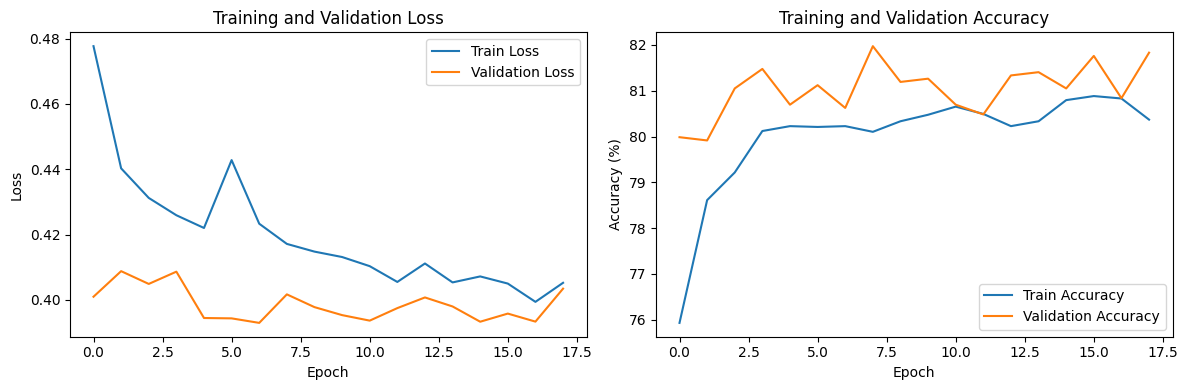

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from collections import defaultdict

# Early stopping class
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='best_model.pt'):
        """
        Args:
            patience (int): How many epochs to wait after last improvement
            verbose (bool): If True, prints improvement messages
            delta (float): Minimum change to qualify as improvement
            path (str): Path for saving the checkpoint
        """
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_accuracy = 0
        
    def __call__(self, val_accuracy, model):
        score = val_accuracy
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
            
    def save_checkpoint(self, model):
        """Saves model when validation accuracy improves"""
        if self.verbose:
            print(f'Validation accuracy improved ({self.best_accuracy:.4f} --> {self.best_score:.4f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.best_accuracy = self.best_score

# Training with DataLoader and Early Stopping
def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, 
                              epochs=100, patience=7, device='cpu'):
    """
    Train model with early stopping and comprehensive logging
    """
    model = model.to(device)
    early_stopping = EarlyStopping(patience=patience, verbose=True)
    
    # For tracking metrics
    history = defaultdict(list)
    best_accuracy = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            total_loss += loss.item()
            
            # Calculate training accuracy for monitoring
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
        
        train_loss = total_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        
        # Validation phase
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * correct / total
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{epochs}]')
            print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%')
            print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')
        
        # Early stopping check
        early_stopping(val_accuracy, model)
        
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pt'))
    
    return model, history

RANDOM_SEED = 19
scaler = StandardScaler()

df = pd.read_csv("../data/interim/telco_customer_churn_preprocessed.csv")

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Scale features
X_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(
    X_train[['tenure', 'MonthlyCharges', 'TotalCharges']]
)
X_test[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
    X_test[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

# Apply conversion to train and test sets
X_train = convert_bool_to_int(X_train)
X_test = convert_bool_to_int(X_test)

# Create evaluation dataset
eval_data = X_test.copy()
eval_data["Churn"] = y_test
df_train = pd.concat([X_train, y_train], axis=1)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader with optimized settings
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Using smaller batch size and pin_memory for faster data transfer
train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True,
    num_workers=2,  # Parallel data loading
    pin_memory=True  # Faster CPU to GPU transfer
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Initialize model
model = FlexibleMLP(
    input_size=X_train.shape[1],
    hidden_sizes=[256, 128, 64],
    output_size=2,
    activation='relu',
    dropout=0.3,
    batch_norm=True
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train with early stopping
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model, history = train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100,  # Increased max epochs, early stopping will handle
    patience=10,  # Stop if no improvement for 10 epochs
    device=device
)

# Final evaluation
model.eval()
correct = 0
total = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted.cpu() == batch_y).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.numpy())

final_accuracy = 100 * correct / total
print(f"\nFinal Test Accuracy: {final_accuracy:.2f}%")

# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Training and Validation Loss')

ax2.plot(history['train_accuracy'], label='Train Accuracy')
ax2.plot(history['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.set_title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

Threshold: 0.10 | Recall: 0.9599 | Precision: 0.3827 | F1: 0.5473
Threshold: 0.15 | Recall: 0.9305 | Precision: 0.4291 | F1: 0.5873
Threshold: 0.20 | Recall: 0.8930 | Precision: 0.4671 | F1: 0.6134
Threshold: 0.25 | Recall: 0.8396 | Precision: 0.5056 | F1: 0.6312
Threshold: 0.30 | Recall: 0.7674 | Precision: 0.5315 | F1: 0.6280
Threshold: 0.35 | Recall: 0.7086 | Precision: 0.5662 | F1: 0.6295
Threshold: 0.40 | Recall: 0.6390 | Precision: 0.6192 | F1: 0.6289
Threshold: 0.45 | Recall: 0.5588 | Precision: 0.6614 | F1: 0.6058
Threshold: 0.50 | Recall: 0.5027 | Precision: 0.7344 | F1: 0.5968
Threshold: 0.55 | Recall: 0.3877 | Precision: 0.7632 | F1: 0.5142
Threshold: 0.60 | Recall: 0.2246 | Precision: 0.8000 | F1: 0.3507
Threshold: 0.65 | Recall: 0.1203 | Precision: 0.7895 | F1: 0.2088
Threshold: 0.70 | Recall: 0.0428 | Precision: 0.8889 | F1: 0.0816
Threshold: 0.75 | Recall: 0.0080 | Precision: 1.0000 | F1: 0.0159
Threshold: 0.80 | Recall: 0.0000 | Precision: 0.0000 | F1: 0.0000
Threshold:

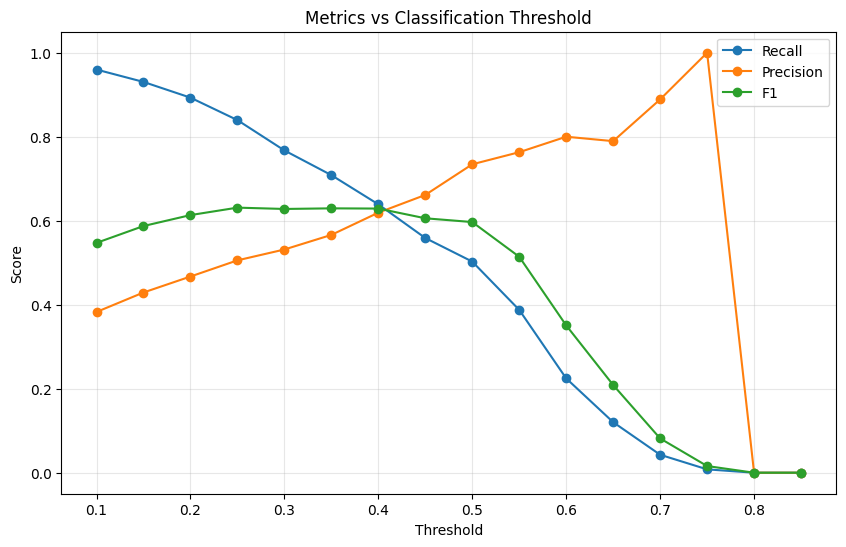


New recall with threshold 0.3: 0.7674


In [17]:
# Use lower threshold for predictions
optimal_threshold = find_best_threshold(model, None, X_test_tensor, y_test_tensor)

# Make predictions with new threshold
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    probs = torch.softmax(outputs, dim=1)[:, 1]
    # Use lower threshold (e.g., 0.3 instead of 0.5)
    y_pred_new = (probs >= 0.3).int()  # Adjust threshold as needed
    
new_recall = recall_score(y_test_tensor.cpu().numpy(), y_pred_new.cpu().numpy())
print(f"\nNew recall with threshold 0.3: {new_recall:.4f}")

Let's use Threshold: 0.25 | Recall: 0.8396 | Precision: 0.5056 | F1: 0.6312

In [ ]:
scaler = StandardScaler()
RANDOM_SEED = 19

# Convert boolean columns to int (0/1) in the DataFrames
def convert_bool_to_int(df):
    """Convert boolean columns to int type"""
    df_converted = df.copy()
    for col in df_converted.select_dtypes(include=['bool']).columns:
        df_converted[col] = df_converted[col].astype(int)
    return df_converted

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# imputation for TotalCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
# making some columns binary
df['MultipleLines'] = df['MultipleLines'].apply(lambda value: 'No' if value=='No phone service' else value)
columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in columns:
    df[col] = df[col].apply(lambda value: 'No' if value=='No internet service' else value)
# converting no-yes columns to 0-1 (also female-male, alphabetical order so 0-1)
mapping = {'Yes': True, 'No': False, 'Male': True, 'Female': False}
no_yes_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'Churn'] + columns
df[no_yes_cols] = df[no_yes_cols].map(lambda value: mapping[value])
# senior citizen to bool
df['SeniorCitizen'] = df['SeniorCitizen'].apply(lambda value: bool(value))
# one-hot encoding for the rest
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Scale features
X_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(
    X_train[['tenure', 'MonthlyCharges', 'TotalCharges']]
)
X_test[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
    X_test[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

# Apply conversion to train and test sets
X_train = convert_bool_to_int(X_train)
X_test = convert_bool_to_int(X_test)

# Create evaluation dataset
eval_data = X_test.copy()
eval_data["Churn"] = y_test
df_train = pd.concat([X_train, y_train], axis=1)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader with optimized settings
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Using smaller batch size and pin_memory for faster data transfer
train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True,
    num_workers=2,  # Parallel data loading
    pin_memory=True  # Faster CPU to GPU transfer
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [10]:
from utils.pipelines import create_preprocessing_pipeline
from torch.utils.data import DataLoader, TensorDataset
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_SEED = 19

df = pd.read_csv("../data/interim/telco_customer_churn_preprocessed.csv")

X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

pipeline = create_preprocessing_pipeline()

pipeline.fit(X_train)

X_train_tensor = pipeline.transform(X_train)
X_test_tensor = pipeline.transform(X_test)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create DataLoader with optimized settings
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True,
    num_workers=2,  
    pin_memory=True  
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)